# Book - Modern Time Series Forecasting with Python

## Chapter 05 - Moving Average (MA) and ARMA Models

### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.24.4
* statsmodels: 0.14.1
* sklearn: 1.3.2
* scipy: 1.10.1
* seaborn: 0.13.2


### Implementing ARMA models with Statsmodels

#### Loading libries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import shapiro, jarque_bera
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

#### Load the Dataset

In [4]:
# --- Load and Prepare Data ---
print("--- Load and Prepare Data ---")
sunspots = sm.datasets.sunspots.load_pandas().data['SUNACTIVITY']
sunspots.index = pd.Index(sm.tsa.datetools.dates_from_range('1700', '2008'))
#del sunspots["YEAR"] # Remove the original YEAR column if present
data_series = sunspots # Use the variable name 'data_series'


--- Load and Prepare Data ---


#### Visualize Data

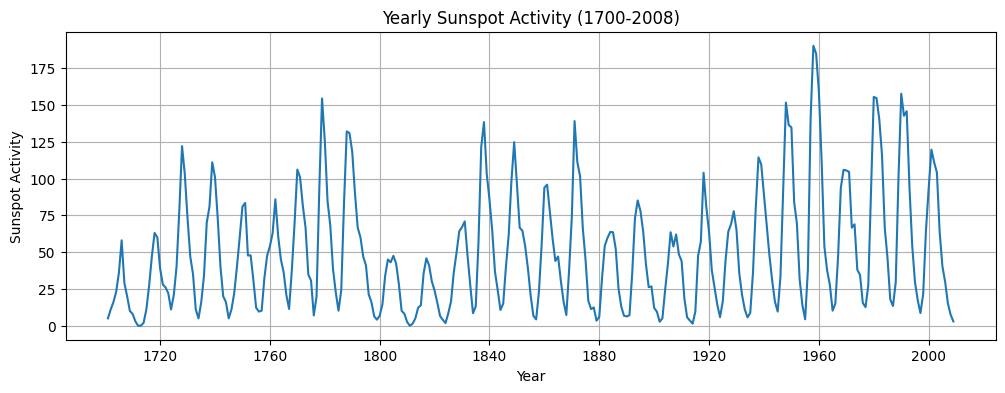

In [3]:
# Visualize the data
plt.figure(figsize=(12, 4))
plt.plot(data_series)
plt.title('Yearly Sunspot Activity (1700-2008)')
plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.grid(True)
plt.show()

#### Check stationarity 

In [4]:
# Check stationarity
print("\n--- Stationarity Checks ---")
adf_result = adfuller(data_series, regression='c')
kpss_result = kpss(data_series, regression='c', nlags='auto')
print(f'ADF Test p-value: {adf_result[1]:.4f}')
print(f'KPSS Test p-value: {kpss_result[1]:.4f}')


--- Stationarity Checks ---
ADF Test p-value: 0.0531
KPSS Test p-value: 0.0163


#### Difference the Series to Achieve Stationarity

In [5]:
# Interpretation: ADF p-value is larger then 0.05 (<0.05), failed rejecting unit root.
# KPSS p-value is small (>0.05), failing to reject stationarity around a constant.
# Conclusion: Data appears non stationary, differencing (d=1) is appropriate.

d = 1 # differencing
data_series  = sunspots.diff(d).dropna()

#### ACF and PACF Plots


---  Identify Candidate Orders (p, q) ---


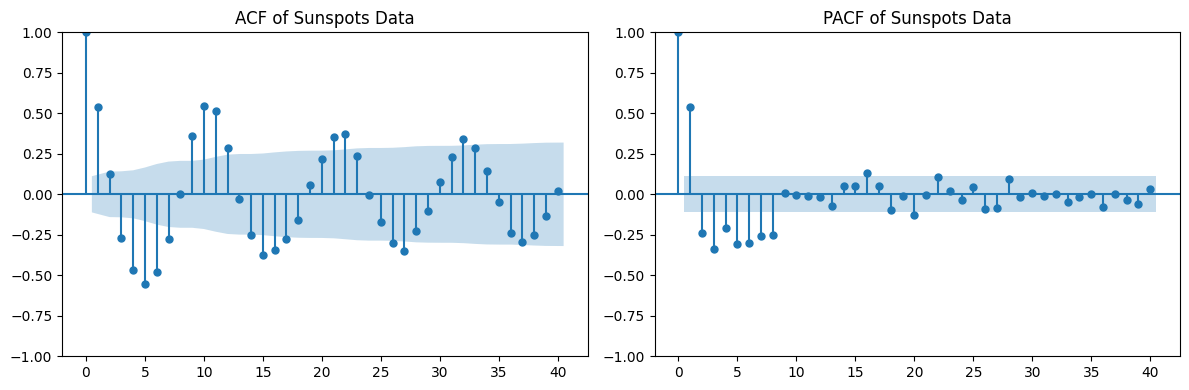

In [6]:
# --- Identify Candidate Orders (p, q) ---
print("\n---  Identify Candidate Orders (p, q) ---")

# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(data_series, lags=40, ax=axes[0], title='ACF of Sunspots Data')
plot_pacf(data_series, lags=40, ax=axes[1], method='ywm', title='PACF of Sunspots Data')
plt.tight_layout()
plt.show()

#### Information Criteria Search (BIC)

In [7]:
# Information Criteria Search (BIC)
print("\n--- Information Criteria Search (BIC) ---")
print("\n--- Series already differenced d=1 ---")
max_p = 5
max_q = 3
p_range = range(max_p + 1)
q_range = range(max_q + 1)

best_bic = np.inf
best_order = None
bic_results = {}

d = 0  # Series already differenced d=1, data_series = data_series  = sunspots.diff(d).dropna(), where d =1

for p_i in p_range:
    for q_i in q_range:
        if p_i == 0 and q_i == 0:
            continue
        current_order = (p_i, d, q_i)
        try:
            model = ARIMA(data_series, order=current_order, trend='c')
            results = model.fit(method_kwargs={'maxiter': 200})
            bic_results[current_order] = results.bic
            if results.bic < best_bic:
                best_bic = results.bic
                best_order = current_order
        except Exception as e:
            bic_results[current_order] = np.inf
            continue

if best_order is None:
    print("No model produced a valid BIC. Check if 'd' is defined and the data has no NaNs.")
else:
    print(f"Best order found by BIC: {best_order} (BIC: {best_bic:.2f})")
    p, d, q = best_order
    print(f"Proceeding with candidate model: ARMA({p},{q})")



--- Information Criteria Search (BIC) ---

--- Series already differenced d=1 ---
Best order found by BIC: (2, 0, 2) (BIC: 2600.65)
Proceeding with candidate model: ARMA(2,2)


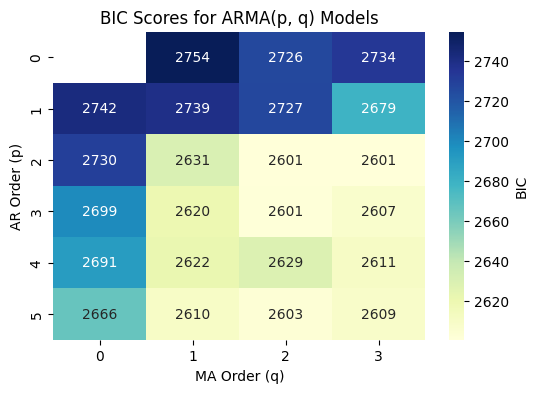

In [8]:
# Reshape the BIC results into a DataFrame
bic_matrix = pd.DataFrame(np.full((max_p+1, max_q+1), np.nan),
                          index=range(max_p+1), columns=range(max_q+1))
for (p_i, _, q_i), bic_val in bic_results.items():
    if bic_val != np.inf:
        bic_matrix.loc[p_i, q_i] = bic_val

# Plot heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(bic_matrix, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'BIC'})
plt.title("BIC Scores for ARMA(p, q) Models")
plt.xlabel("MA Order (q)")
plt.ylabel("AR Order (p)")
plt.show()


#### Fit the ARMA({p},{q}) Model

In [9]:
# --- Estimate Candidate Model ---
print(f"\n--- Estimate ARMA({p},{q}) Model ---")
final_model = ARIMA(data_series, order=(p, d, q), trend='c')
try:
    final_results = final_model.fit()
    print("Final model fitting complete.")
except Exception as e:
    print(f"Error fitting final model: {e}")
    final_results = None


--- Estimate ARMA(2,2) Model ---
Final model fitting complete.


In [10]:
print(f"\n--- Perform Diagnostics for ARMA({p},{q}) ---\n\n\n")
print(final_results.summary())

# Residual Analysis
residuals = final_results.resid


--- Perform Diagnostics for ARMA(2,2) ---



                               SARIMAX Results                                
Dep. Variable:            SUNACTIVITY   No. Observations:                  308
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1283.136
Date:                Sun, 07 Dec 2025   AIC                           2578.271
Time:                        10:18:44   BIC                           2600.652
Sample:                    12-31-1701   HQIC                          2587.220
                         - 12-31-2008                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0802      0.403      0.199      0.843      -0.711       0.871
ar.L1          1.6097      0.027     60.187      0.000       1.557       1.662
ar.L2 

#### Diagnose Residuals


--- Diagnose Residuals ---


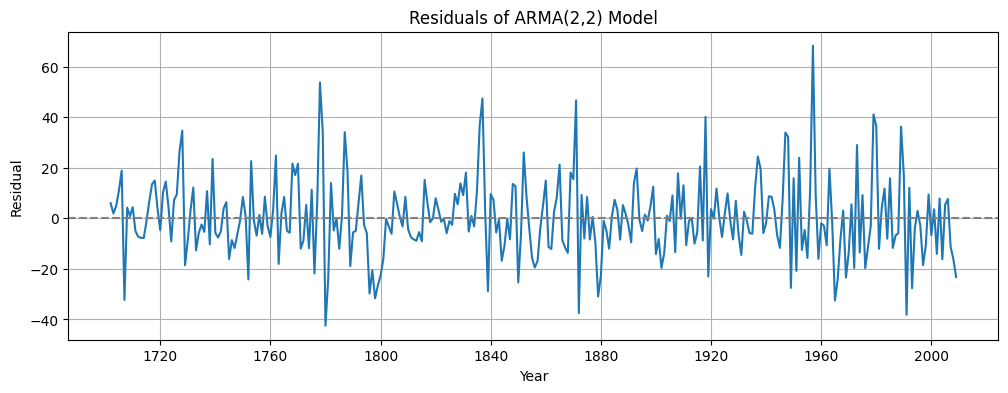

In [11]:
print("\n--- Diagnose Residuals ---")

plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.axhline(0, linestyle='--', color='grey')
plt.title(f'Residuals of ARMA({p},{q}) Model')
plt.xlabel('Year'); plt.ylabel('Residual')
plt.grid(True); plt.show()

#### Plot ACF/PACF of residuals

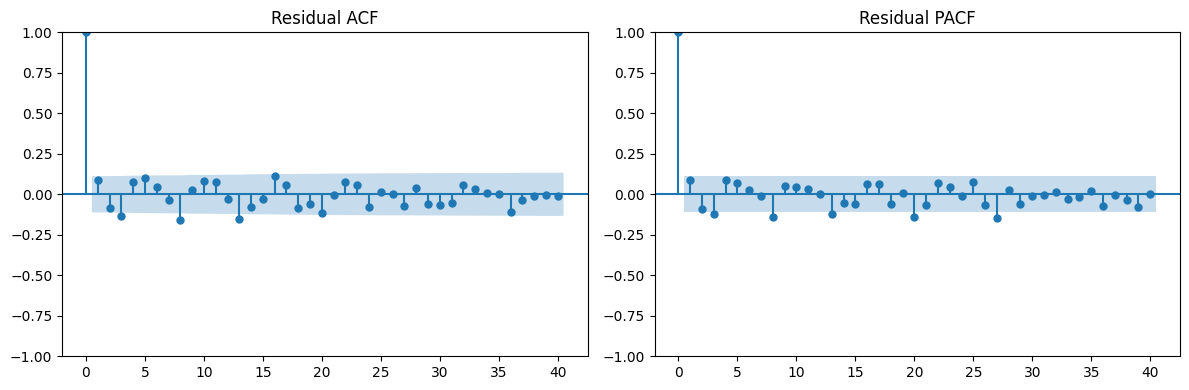

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals, lags=40, ax=axes[0])
axes[0].set_title('Residual ACF')
plot_pacf(residuals, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Residual PACF')
plt.tight_layout()
plt.show()

#### Ljung-Box test on residuals

In [13]:
# Ljung-Box Test
df_adjustment = p + q
lags_lb = list(range(max(1, df_adjustment + 1), min(41, len(residuals)//5), 5))
if not lags_lb: lags_lb = [max(10, df_adjustment + 1)]
lb_test_df = acorr_ljungbox(residuals, lags=lags_lb, return_df=True, model_df=df_adjustment)
print(f"\nLjung-Box Test Results (Adjusted df={df_adjustment}):")
print(lb_test_df)
if (lb_test_df['lb_pvalue'] <= 0.05).any():
    print("Warning: Residuals show significant autocorrelation (Ljung-Box). Model might be inadequate.")
else:
    print("Residuals appear uncorrelated (Ljung-Box).")


Ljung-Box Test Results (Adjusted df=4):
      lb_stat  lb_pvalue
5   15.067922   0.000104
10  26.379640   0.000189
15  37.858505   0.000083
20  51.128771   0.000015
25  56.574540   0.000042
30  61.831716   0.000095
35  64.623501   0.000372
40  69.070476   0.000751


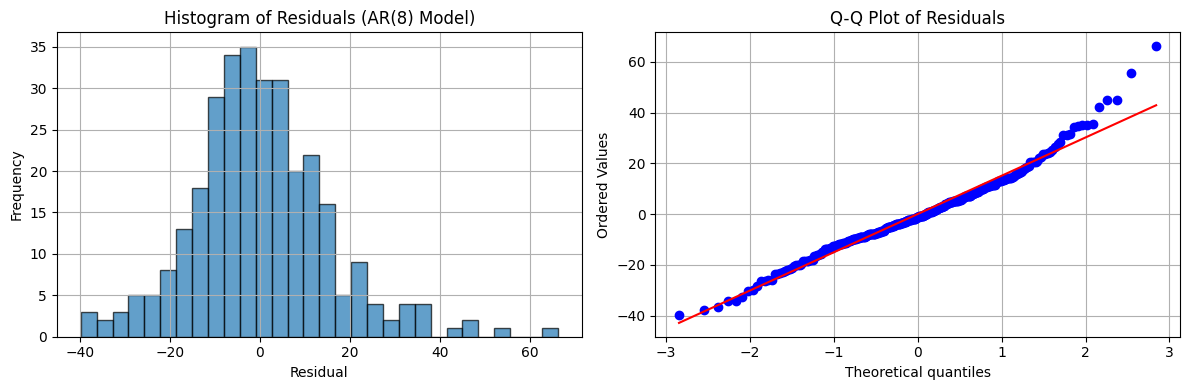

In [14]:
# Create side-by-side plots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of residuals
axs[0].hist(results.resid, bins=30, edgecolor='black', alpha=0.7)
axs[0].set_title('Histogram of Residuals (AR(8) Model)')
axs[0].set_xlabel('Residual')
axs[0].set_ylabel('Frequency')
axs[0].grid(True)

# Q-Q plot of residuals
stats.probplot(results.resid, dist="norm", plot=axs[1])
axs[1].set_title('Q-Q Plot of Residuals')
axs[1].grid(True)

plt.tight_layout()

plt.show()

In [15]:
shapiro_stat, shapiro_p = shapiro(residuals)
print(f'\nShapiro-Wilk Test p-value: {shapiro_p:.4f}')
if shapiro_p <= 0.05: print("Warning: Residuals may not be normally distributed (Shapiro-Wilk).")


Shapiro-Wilk Test p-value: 0.0000


#### Generate Forecasts


--- Step 6 & 7: Generate and Evaluate Forecasts ---

Out-of-Sample Forecast Accuracy:
MAE:  14.1835
RMSE: 18.8203


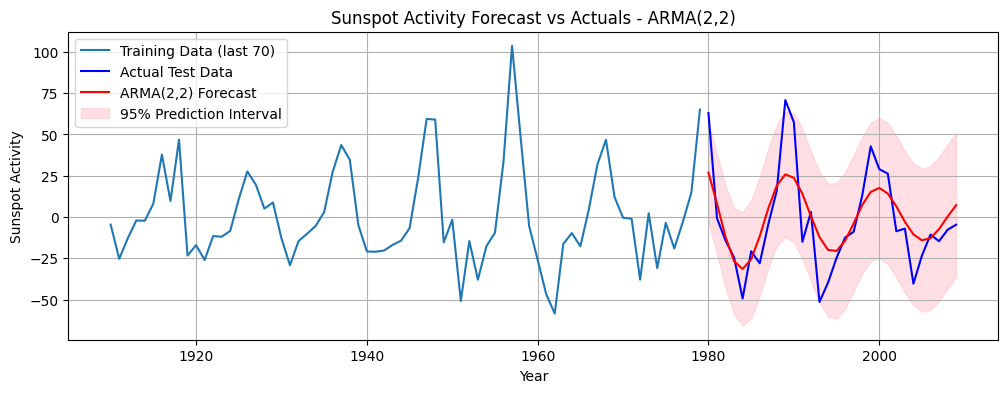

In [16]:
print("\n--- Generate and Evaluate Forecasts ---")
# Split data for evaluation
train_size = len(data_series) - 30 # Hold out last 30 years for testing
train_data, test_data = data_series[0:train_size], data_series[train_size:]

# Refit model on training data ONLY
eval_model = ARIMA(train_data, order=(p, d, q), trend='c')
eval_results = eval_model.fit()



# Forecast the test period
forecast_start = test_data.index[0]
forecast_end = test_data.index[-1]
forecast_obj = eval_results.get_prediction(start=forecast_start, end=forecast_end)
forecasts = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05) # 95% intervals

# Evaluate
actual_values = test_data[:len(forecasts)]
mae = mean_absolute_error(actual_values, forecasts)
rmse = np.sqrt(mean_squared_error(actual_values, forecasts))
print("\nOut-of-Sample Forecast Accuracy:")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

# Visualize
plt.figure(figsize=(12, 4))
plt.plot(train_data.index[-70:], train_data.iloc[-70:], label='Training Data (last 70)')
plt.plot(test_data.index, actual_values, label='Actual Test Data', color='blue')
plt.plot(forecasts.index, forecasts, label=f'ARMA({p},{q}) Forecast', color='red')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                 color='pink', alpha=0.5, label='95% Prediction Interval')
plt.title(f'Sunspot Activity Forecast vs Actuals - ARMA({p},{q})')
plt.xlabel('Year'); plt.ylabel('Sunspot Activity')
plt.legend(loc='upper left'); plt.grid(True); 
plt.savefig('./Figure 5.9.png', dpi=600, bbox_inches='tight')
plt.show()



In [17]:
# Assume actual values are available for comparison (e.g., first 30 future years)
y_true = actual_values  # Substitute with actual future values if available
y_pred = forecasts  # Corresponding model forecasts

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 14.18
RMSE: 18.82
